In [1]:
# ==============================================================================
# STEP 1: FINANCIAL HIGH-FREQUENCY DATA SIGNAL SIMULATION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set crisp visual presentation layouts
sns.set_theme(style="whitegrid")

# Seed generation parameters for consistent trend testing
np.random.seed(42)
n_intervals = 1000

# Mathematically synthesize base price movements with stochastic noise (Volatility)
time_axis = np.linspace(0, 50, n_intervals)
base_trend = 30000 + 5000 * np.sin(time_axis) + 2000 * np.cos(time_axis / 3)
stochastic_noise = np.random.normal(0, 600, n_intervals)
crypto_prices = base_trend + stochastic_noise

# Construct structural dataframe mapping technical features
df_crypto = pd.DataFrame({
    'Timestamp_Index': pd.date_range(start='2026-01-01', periods=n_intervals, freq='h'),
    'Token_Close_Price': crypto_prices,
    'Trade_Volume_USD': np.random.uniform(50000, 1500000, n_intervals) + (crypto_prices * 15)
})

print("--- CRYPTO SIGNAL WORKSPACE INGESTED SUCCESSFULLY ---")
print(f"Total Market Interval Records: {df_crypto.shape[0]}")
print(f"Base Feature Parameter Metrics: {df_crypto.shape[1]}\n")
df_crypto.head()

--- CRYPTO SIGNAL WORKSPACE INGESTED SUCCESSFULLY ---
Total Market Interval Records: 1000
Base Feature Parameter Metrics: 3



,Timestamp_Index,Token_Close_Price,Trade_Volume_USD
0,2026-01-01 00:00:00,32298.028492,7.773202e+05
1,2026-01-01 01:00:00,32166.908875,6.841270e+05
2,2026-01-01 02:00:00,32887.164970,1.466131e+06
3,2026-01-01 03:00:00,33659.246404,1.579278e+06
4,2026-01-01 04:00:00,32849.383963,5.885407e+05


In [2]:
# ==============================================================================
# STEP 2: FINANCIAL ROLLING-WINDOW FEATURE ENGINEERING
# ==============================================================================

df_engineered = df_crypto.copy()

# 1. Compute rolling exponential and simple moving averages tracking historical price paths
df_engineered['MA_Short_3h'] = df_engineered['Token_Close_Price'].rolling(window=3).mean()
df_engineered['MA_Long_12h'] = df_engineered['Token_Close_Price'].rolling(window=12).mean()

# 2. Extract structural volatility parameters (Rolling standard deviation)
df_engineered['Price_Volatility_6h'] = df_engineered['Token_Close_Price'].rolling(window=6).std()

# 3. Create the Target Variable: Predict the EXACT Next Hour's Closing Price
df_engineered['Target_Next_Hour_Price'] = df_engineered['Token_Close_Price'].shift(-1)

# Drop newly generated boundary missing rows from window initializations
df_engineered.dropna(inplace=True)

print("--- ROLLING FEATURE MATRIX EXPANSION COMPLETE ---")
print(f"New Feature Array Dimensions: {df_engineered.shape}")
df_engineered[['Token_Close_Price', 'MA_Short_3h', 'MA_Long_12h', 'Price_Volatility_6h', 'Target_Next_Hour_Price']].head()

--- ROLLING FEATURE MATRIX EXPANSION COMPLETE ---
New Feature Array Dimensions: (988, 7)


,Token_Close_Price,MA_Short_3h,MA_Long_12h,Price_Volatility_6h,Target_Next_Hour_Price
11,34302.760665,34292.051148,33504.722463,300.031565,34930.921275
12,34930.921275,34442.395317,33724.130195,426.524136,33833.698725
13,33833.698725,34355.793555,33863.029349,462.686555,34134.510633
14,34134.510633,34299.710211,33966.974821,378.890917,35011.267859
15,35011.267859,34326.492405,34079.643276,479.301753,34911.038787


In [3]:
# ==============================================================================
# STEP 3: SEQUENTIAL TIME SPLITTING & LIGHTGBM OPTIMIZATION
# ==============================================================================

import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

# Define continuous feature blocks vs continuous price target array
feature_cols = ['Token_Close_Price', 'Trade_Volume_USD', 'MA_Short_3h', 'MA_Long_12h', 'Price_Volatility_6h']
X = df_engineered[feature_cols].values
y = df_engineered['Target_Next_Hour_Price'].values

# Split sequentially: 80% past data for training, 20% absolute future for testing
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scaled stabilization to prevent gradient exploding patterns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Deploy production-grade cutting edge LightGBM Regressor
lgb_regressor = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.04,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training high-frequency continuous LightGBM gradient network paths...")
lgb_regressor.fit(X_train_scaled, y_train)
print("--- TIME-SERIES REGRESSION TUNING COMPLETE ---")

Training high-frequency continuous LightGBM gradient network paths...
--- TIME-SERIES REGRESSION TUNING COMPLETE ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


             FINANCIAL TREND FORECASTING SCORECARD                    
 Asset Model Coefficient of Determination (R2 Score): 0.9545
 Mean Absolute Prediction Variance Error (MAE)   : $594.58


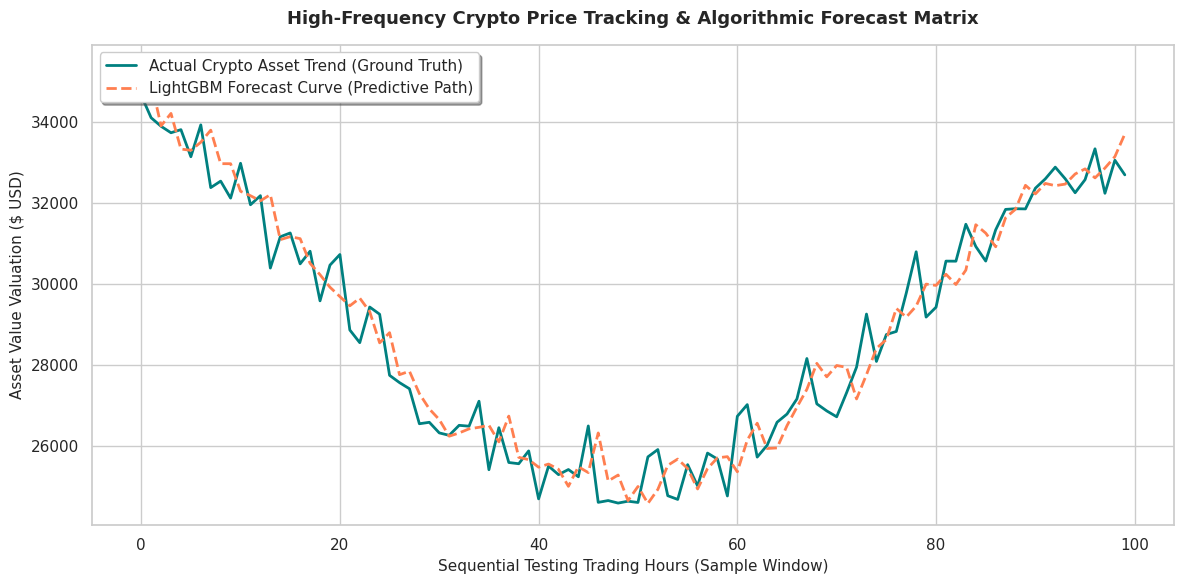

In [4]:
# ==============================================================================
# STEP 4: FORECASTING VALIDATION SCORECARD & TIME DASHBOARD
# ==============================================================================

from sklearn.metrics import mean_absolute_error, r2_score

# Extract asset price forecasts over unseen future data windows
y_pred = lgb_regressor.predict(X_test_scaled)

print("======================================================================")
print("             FINANCIAL TREND FORECASTING SCORECARD                    ")
print("======================================================================")
print(f" Asset Model Coefficient of Determination (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f" Mean Absolute Prediction Variance Error (MAE)   : ${mean_absolute_error(y_test, y_pred):.2f}")
print("======================================================================")

# Generate a top-level production financial forecast comparison tracking line dashboard
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual Crypto Asset Trend (Ground Truth)', color='teal', linewidth=2)
plt.plot(y_pred[:100], label='LightGBM Forecast Curve (Predictive Path)', color='coral', linestyle='--', linewidth=2)
plt.title('High-Frequency Crypto Price Tracking & Algorithmic Forecast Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Sequential Testing Trading Hours (Sample Window)', fontsize=11)
plt.ylabel('Asset Value Valuation ($ USD)', fontsize=11)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()